In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.pipeline import make_pipeline

In [2]:
x = 6 * np.random.rand(200, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(200, 1) # this is the target variable with some noise which uses a quadratic function

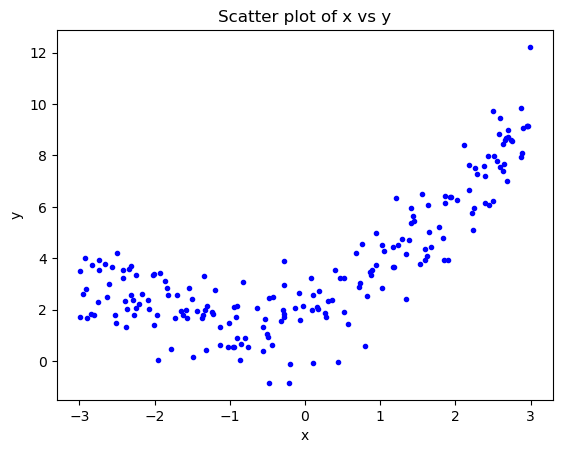

In [3]:
plt.plot(x,y,"b.")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x vs y")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.5386712415188356

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_59225/1168999541.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  plt.plot(X_train, y_train,"b.", color='blue')


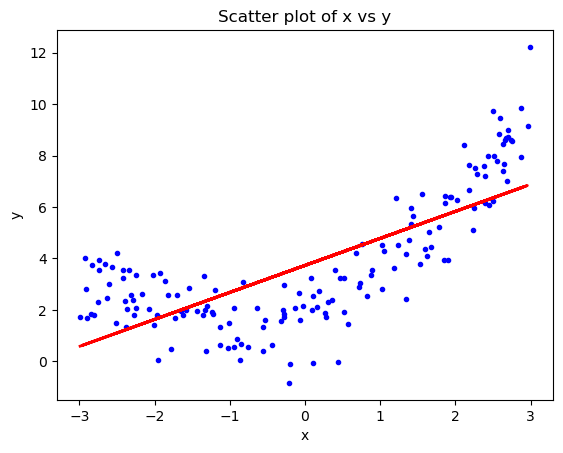

In [5]:
plt.plot(X_train, y_train,"b.", color='blue')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x vs y")
plt.plot(X_test,y_pred, color='red', linewidth=2)

When you see include_bias=True in something like PolynomialFeatures from scikit-learn, it’s about whether to add the bias (intercept) column to your feature matrix 
𝑋

In [6]:
# applying polynomial regression
poly = PolynomialFeatures(degree=2,include_bias=True)  # include_bias=True adds a column of ones for the intercept term
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [7]:
print(X_train[0])
print(X_train_poly[0])

[-1.31646336]
[ 1.         -1.31646336  1.73307579]


In [8]:
lr = LinearRegression()
lr.fit(X_train_poly,y_train)
y_pred_poly = lr.predict(X_test_poly)

In [9]:
r2_score(y_test,y_pred_poly)

0.8368404559742539

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_59225/2107727354.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  plt.plot(X_train_poly, y_train,"b.", color='blue')


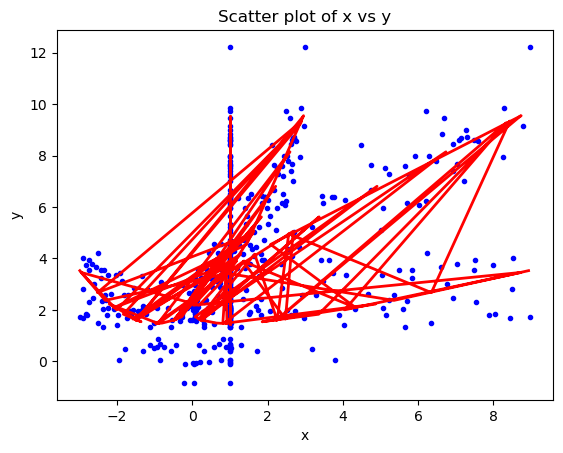

In [10]:
plt.plot(X_train_poly, y_train,"b.", color='blue')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of x vs y")
plt.plot(X_test_poly, y_pred_poly, color='red', linewidth=2)

In [11]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

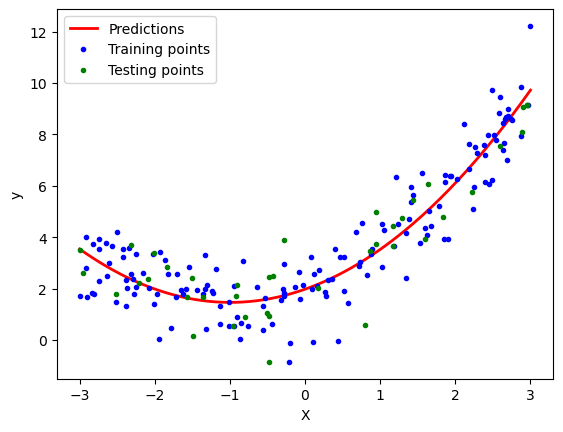

In [12]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [23]:
x.shape


(200, 1)

In [26]:
# polynomial regression

from sklearn.pipeline import Pipeline
def polynomial_regression(degree): #you pass the degree of the polynomial to specify how high the polynomial should be
    X_new = np.linspace(-3, 3, 200).reshape(200, 1) #creates 200 evenly spaced points between -3 and 3 which reshapes it to a 2D array
    X_new_poly = poly.transform(X_new) #transforms the new X values to polynomial features
    
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()

    """
    PolynomialFeatures → generates all powers up to degree (but no bias column since LinearRegression can handle intercept).

    StandardScaler → normalizes features so that large powers (like 𝑥^5) don’t dominate.

    LinearRegression → standard ordinary least squares.
    """
    polynomial_regression = Pipeline([
    ("poly_features", polybig_features),
    ("std_scaler", std_scaler),
    ("lin_reg", lin_reg),
    ])
    """
    This Pipeline automatically:

    Expands features to polynomial terms.

    Scales them.

    Fits a linear regression.

    Benefit: Keeps transformations consistent during training & prediction
    """

    polynomial_regression.fit(x, y) # fits the data to the polynomial regression model
    y_newbig = polynomial_regression.predict(X_new) # predicts the new X values using the polynomial regression model

    plt.plot(X_new, y_newbig, "r-", linewidth=2, label="Predictions")
    plt.plot(X_train, y_train, "b.", label='Training points')

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()




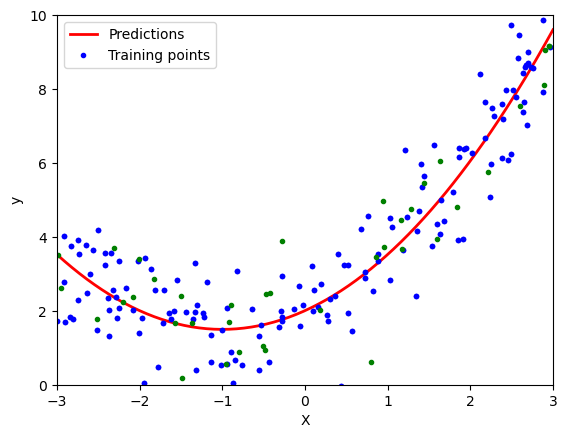

In [27]:
polynomial_regression(2)  # you can change the degree to see how it affects the fit

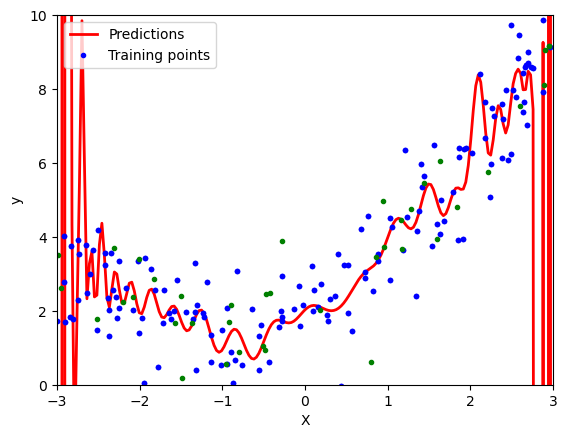

In [28]:
polynomial_regression(290)